In [1]:

import numpy as np
from matplotlib import pyplot as plt
from api.model_controller import ModelJob
from api.file_controller import FileController
import os
os.environ['nnUNet_raw'] = '/home/simon/Data/nnUNet_raw'
os.environ['nnUNet_preprocessed'] = '/home/simon/Data/nnUNet_preprocessed'
os.environ['nnUNet_results'] = '/home/simon/Data/nnUNet_results'

In [2]:
file_controller = FileController()

In [13]:
torsion_exam = file_controller.get_examination('dxutstbwuf')

In [14]:
type(torsion_exam)

examination.TorsionExamination

In [16]:
torsion_exam.landmarks

defaultdict(dict, {'femur': {}})

In [5]:
torsion_exam.hip_mask.save_image('/home/simon/Downloads/gui_test/hip_mask.nii.gz')
torsion_exam.knee_mask.save_image('/home/simon/Downloads/gui_test/knee_mask.nii.gz')
torsion_exam.ankle_mask.save_image('/home/simon/Downloads/gui_test/ankle_mask.nii.gz')

In [17]:
ModelJob.compute_torsional_alignment(torsion_exam)

In [32]:
hip_layer = torsion_exam.landmarks['femur']['right']['hip_start'][-1]
knee_layer = torsion_exam.landmarks['femur']['right']['knee_start'][-1]

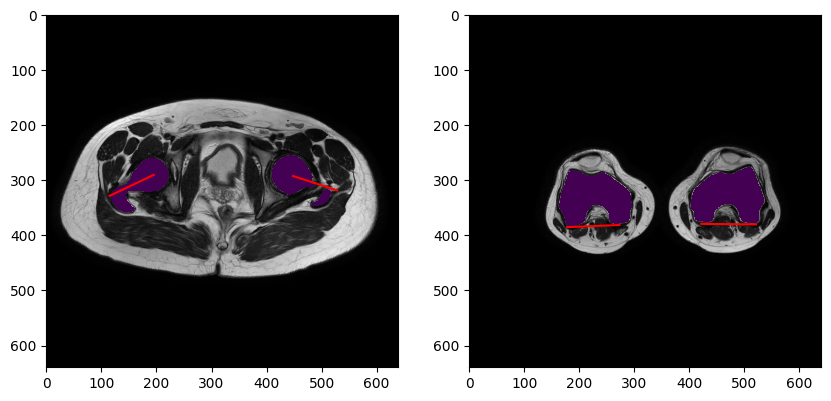

In [35]:
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(10, 20))
ax[0].imshow(torsion_exam.hip.array[:, :, hip_layer].T, cmap='gray')
ax[0].imshow(np.where(torsion_exam.hip_mask.array[:, :, hip_layer] == 0, np.nan, torsion_exam.hip_mask.array[:, :, hip_layer]).T)
ax[0].plot([torsion_exam.landmarks['femur']['right']['hip_start'][0], torsion_exam.landmarks['femur']['right']['hip_end'][0]], [torsion_exam.landmarks['femur']['right']['hip_start'][1], torsion_exam.landmarks['femur']['right']['hip_end'][1]], 'r')
ax[0].plot([torsion_exam.landmarks['femur']['left']['hip_start'][0], torsion_exam.landmarks['femur']['left']['hip_end'][0]], [torsion_exam.landmarks['femur']['left']['hip_start'][1], torsion_exam.landmarks['femur']['left']['hip_end'][1]], 'r')
ax[1].imshow(torsion_exam.knee.array[:, :, knee_layer].T, cmap='gray')
ax[1].imshow(np.where(torsion_exam.knee_mask.array[:, :, knee_layer] == 0, np.nan, torsion_exam.knee_mask.array[:, :, knee_layer]).T)
ax[1].plot([torsion_exam.landmarks['femur']['right']['knee_start'][0], torsion_exam.landmarks['femur']['right']['knee_end'][0]], [torsion_exam.landmarks['femur']['right']['knee_start'][1], torsion_exam.landmarks['femur']['right']['knee_end'][1]], 'r')
ax[1].plot([torsion_exam.landmarks['femur']['left']['knee_start'][0], torsion_exam.landmarks['femur']['left']['knee_end'][0]], [torsion_exam.landmarks['femur']['left']['knee_start'][1], torsion_exam.landmarks['femur']['left']['knee_end'][1]], 'r')
plt.show()

In [36]:
ankle_layer = int(torsion_exam.landmarks['tibia']['left']['ankle_start'][-1])
knee_layer = int(torsion_exam.landmarks['tibia']['left']['knee_start'][-1])

In [37]:
np.unique(torsion_exam.ankle_mask.array[:, :, ankle_layer])

array([0., 1., 2.])

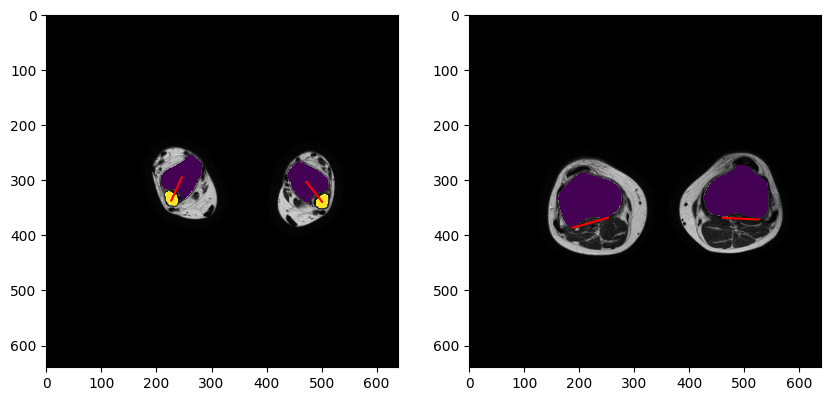

In [40]:
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(10, 20))
ax[0].imshow(torsion_exam.ankle.array[:, :, ankle_layer].T, cmap='gray')
ax[0].imshow(np.where(torsion_exam.ankle_mask.array[:, :, ankle_layer] == 0, np.nan, torsion_exam.ankle_mask.array[:, :, ankle_layer]).T)
ax[0].plot([torsion_exam.landmarks['tibia']['right']['ankle_start'][0], torsion_exam.landmarks['tibia']['right']['ankle_end'][0]], [torsion_exam.landmarks['tibia']['right']['ankle_start'][1], torsion_exam.landmarks['tibia']['right']['ankle_end'][1]], 'r')
ax[0].plot([torsion_exam.landmarks['tibia']['left']['ankle_start'][0], torsion_exam.landmarks['tibia']['left']['ankle_end'][0]], [torsion_exam.landmarks['tibia']['left']['ankle_start'][1], torsion_exam.landmarks['tibia']['left']['ankle_end'][1]], 'r')
ax[1].imshow(torsion_exam.knee.array[:, :, knee_layer].T, cmap='grey')
ax[1].imshow(np.where(torsion_exam.knee_mask.array[:, :, knee_layer] == 0, np.nan, torsion_exam.knee_mask.array[:, :, knee_layer]).T)
ax[1].plot([torsion_exam.landmarks['tibia']['right']['knee_start'][0], torsion_exam.landmarks['tibia']['right']['knee_end'][0]], [torsion_exam.landmarks['tibia']['right']['knee_start'][1], torsion_exam.landmarks['tibia']['right']['knee_end'][1]], 'r')
ax[1].plot([torsion_exam.landmarks['tibia']['left']['knee_start'][0], torsion_exam.landmarks['tibia']['left']['knee_end'][0]], [torsion_exam.landmarks['tibia']['left']['knee_start'][1], torsion_exam.landmarks['tibia']['left']['knee_end'][1]], 'r')
plt.show()

In [41]:
torsion_exam.get_torsion_values()

{'femoral_torsion_left': 17.42543604030541,
 'femoral_torsion_right': 22.996688362337355,
 'tibial_torsion_left': 49.17271725621521,
 'tibial_torsion_right': 50.09834582809147}